In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path = "input/"

nlg_N_2_L_100 = np.loadtxt(path + "nlg_N_2_L_100.dat", dtype = int)
nlg_N_4_L_100 = np.loadtxt(path + "nlg_N_4_L_100.dat", dtype = int)
nlg_N_6_L_100 = np.loadtxt(path + "nlg_N_6_L_100.dat", dtype = int)

nodes_raw_N2_L100 = np.loadtxt(path + "wezly_N_2_L_100.dat")
nodes_raw_N4_L100 = np.loadtxt(path + "wezly_N_4_L100.dat")
nodes_raw_N6_L100 = np.loadtxt(path + "wezly_N_6_L100.dat")

L = 100
omega = 10 
omega_t = 10/27211

In [3]:
nlgN2 = {(k, i): l for k, i, l in nlg_N_2_L_100}
nlgN4 = {(k, i): l for k, i, l in nlg_N_4_L_100}
nlgN6 = {(k, i): l for k, i, l in nlg_N_6_L_100}

def createMesh(nodes_raw):
    id = nodes_raw[:, 0].astype(int)

    size = id.max()
    XY = np.zeros((size + 1, 2), dtype = float)
    XY[id, 0] = nodes_raw[:, 1]*(L/100)
    XY[id, 1] = nodes_raw[:, 2]*(L/100)
    return XY

def f1(xi):
    return (1 - xi)/2

def f2(xi):
    return (1 + xi)/2 


In [4]:
XY_N2 = createMesh(nodes_raw_N2_L100)
XY_N4 = createMesh(nodes_raw_N4_L100)
XY_N6 = createMesh(nodes_raw_N6_L100)

In [5]:
def g1(xi1, xi2):
    return f1(xi1)*f1(xi2)

def g2(xi1, xi2):
    return f2(xi1)*f1(xi2)

def g3(xi1, xi2):
    return f1(xi1)*f2(xi2)

def g4(xi1, xi2):
    return f2(xi1)*f2(xi2)

In [6]:
gi = np.array([g1, g2, g3, g4])

In [7]:
def x_of_xi(k, xi1, xi2, nlg, XY):
    l1 = nlg[(k,1)]; l2 = nlg[(k,2)]; l3 = nlg[(k,3)]; l4 = nlg[(k,4)]
    x1, x2, x3, x4 = XY[l1,0], XY[l2,0], XY[l3,0], XY[l4,0]
    return x1*g1(xi1,xi2) + x2*g2(xi1,xi2) + x3*g3(xi1,xi2) + x4*g4(xi1,xi2)

def y_of_xi(k, xi1, xi2, nlg, XY):
    l1 = nlg[(k,1)]; l2 = nlg[(k,2)]; l3 = nlg[(k,3)]; l4 = nlg[(k,4)]
    y1, y2, y3, y4 = XY[l1,1], XY[l2,1], XY[l3,1], XY[l4,1]
    return y1*g1(xi1,xi2) + y2*g2(xi1,xi2) + y3*g3(xi1,xi2) + y4*g4(xi1,xi2)

In [8]:
x1N2 = x_of_xi(1, -1, -1, nlgN2, XY_N2)
x2N2 = x_of_xi(1, 1, -1, nlgN2, XY_N2)

x1N4 = x_of_xi(1, -1, -1, nlgN4, XY_N4)
x2N4 = x_of_xi(1, 1, -1, nlgN4, XY_N4)

x1N6 = x_of_xi(1, -1, -1, nlgN6, XY_N6)
x2N6 = x_of_xi(1, 1, -1, nlgN6, XY_N6)

print(aN2 := (np.abs(x1N2) - np.abs(x2N2)), aN4 := (np.abs(x1N4) - np.abs(x2N4)), aN6 := (np.abs(x1N6) - np.abs(x2N6))  )

25.0 12.5 8.3333333333333


In [9]:
def q1(xi):
    return 0.5*xi*(xi - 1)

def q2(xi):
    return (1-xi)*(1+xi)

def q3(xi):
    return 0.5*xi*(xi+1)

In [10]:
def h1(xi1, xi2):
    return q1(xi1)*q1(xi2)

def h2(xi1, xi2):
    return q3(xi1)*q1(xi2)

def h3(xi1, xi2):
    return q1(xi1)*q3(xi2)

def h4(xi1, xi2):
    return q3(xi1)*q3(xi2)

def h5(xi1, xi2):
    return q2(xi1)*q1(xi2)

def h6(xi1, xi2):
    return q3(xi1)*q2(xi2)

def h7(xi1, xi2):
    return q1(xi1)*q2(xi2)

def h8(xi1, xi2):
    return q2(xi1)*q3(xi2)

def h9(xi1, xi2):
    return q2(xi1)*q2(xi2)

H = [h1, h2, h3, h4, h5, h6, h7, h8, h9]

In [11]:
w1 = (18 + np.sqrt(30))/36
w2 = w1
w3 = (18 - np.sqrt(30))/36
w4 = w3

p1 = -np.sqrt((3/7) - (2/7)*np.sqrt(6/5))
p2 = np.sqrt((3/7) - 2/7*np.sqrt(6/5))
p3 = np.sqrt((3/7) + 2/7*np.sqrt(6/5))
p4 = -np.sqrt((3/7) + 2/7*np.sqrt(6/5))

w = np.array([w1, w2, w3, w4])
p = np.array([p1, p2, p3, p4])

In [12]:
def local_S(a):
    a_au = a / 0.05292
    det = 0.25 * a_au**2
    S = np.zeros((9,9), float)
    for i in range(9):
        for j in range(9):
            s_ij = 0.0
            for l in range(4):
                for n in range(4):
                    s_ij += w[l]*w[n] * H[j](p[l], p[n]) * H[i](p[l], p[n])
            S[i,j] = s_ij * det
    return S

In [13]:
loc_sN2 = local_S(aN2)
loc_sN4 = local_S(aN4)
loc_sN6 = local_S(aN6)

det_N2 = (aN2/0.05292)**2*0.25

In [14]:
h = 1
m = 0.067

In [15]:
def local_X(a, k, mesh, nlg):
    det = 0.25*a/0.05292/0.05292
    X = np.zeros((9,9), float)
    for i in range(9):
        for j in range(9):
            x_ij = 0.0
            for l in range(4):
                for n in range(4):
                    x_nm = x_of_xi(k, p[l], p[n], nlg, mesh)
                    x_au = x_nm / 0.05292

                    x_ij += w[l]*w[n] * x_au * H[j](p[l], p[n]) * H[i](p[l], p[n])
            X[i,j] = x_ij * det
    return X

In [16]:
def dHdXi2(hfun, pl, pn):
    delta = 1e-6
    return 0.5*(hfun(pl, pn + delta) - hfun(pl, pn - delta))/delta

def dHdXi1(hfun, pl, pn):
    delta = 1e-6
    return 0.5*(hfun(pl + delta, pn) - hfun(pl - delta, pn))/delta

In [17]:
def local_T():
    T = np.zeros((9, 9), float)
    for i in range(9):
        for j in range(9):
            t_ij = 0.0
            for l in range(4):
                for n in range(4):
                    term_xi1 = dHdXi1(H[j], p[l], p[n])*dHdXi1(H[i], p[l], p[n])
                    term_xi2 = dHdXi2(H[j], p[l], p[n])*dHdXi2(H[i], p[l], p[n])

                    t_ij += w[l]*w[n]*(term_xi1 + term_xi2)
                T[i, j] = t_ij/2/m
    return T

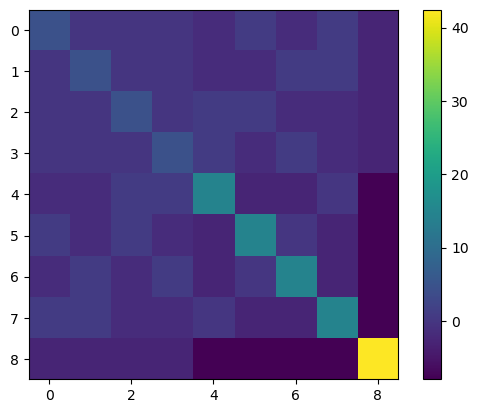

In [18]:
plt.imshow(local_T())
plt.colorbar()

In [19]:
omega = 10 
omega_t = 10/27211

In [20]:
def local_V(a, k, mesh, nlg):
    a_au = a / 0.05292
    det = 0.25 * a_au**2
    V = np.zeros((9,9), float)
    for i in range(9):
        for j in range(9):
            v_ij = 0.0
            for l in range(4):
                for n in range(4):
                    x = x_of_xi(k, p[l], p[n], nlg, mesh)/0.05292
                    y = y_of_xi(k, p[l], p[n], nlg, mesh)/0.05292

                    v_ij += w[l]*w[n] * (x**2 + y**2) * H[j](p[l], p[n]) * H[i](p[l], p[n])
            V[i,j] = 0.5*v_ij * det * m * omega_t**2
    return V

In [21]:
kn2 = 16
kn4 = 64
kn6 = 144

def foundBoundaryNodes(mesh):
    x = mesh[:, 0]
    y = mesh[:, 1]

    xmin, xmax = x[1:].min(), x[1:].max()
    ymin, ymax = y[1:].min(), y[1:].max()
    tol = 1e-8

    boundary_nodes = []
    for i in range(1, mesh.shape[0]):  
        if (abs(x[i] - xmin) < tol or abs(x[i] - xmax) < tol or
            abs(y[i] - ymin) < tol or abs(y[i] - ymax) < tol):
            boundary_nodes.append(i)

    return boundary_nodes

def setBoundaryConditions(bn, S, H):
    for i in bn:
        S[i, :] = 0.0
        S[:, i] = 0.0
        H[i, :] = 0.0
        H[:, i] = 0.0
        S[i, i] = 1.0
        H[i, i] = -1410.0
    return S, H

def SgHg(a, kn, size, mesh, nlg):
    Sg = np.zeros((size + 1, size + 1))
    Hg = np.zeros((size + 1, size + 1))
    Xg = np.zeros((size + 1, size + 1))

    s_loc = local_S(a)
    t_loc = local_T()

    for k in range(1, kn+1):
        v_loc = local_V(a, k, mesh=mesh, nlg=nlg)
        x_loc = local_X(a, k, mesh=mesh, nlg=nlg)


        for i in range(1, 10):
            I = nlg[(k, i)]      
            for j in range(1, 10):
                J = nlg[(k, j)]
                Sg[I, J] += s_loc[i-1, j-1]
                Hg[I, J] += t_loc[i-1, j-1] + v_loc[i-1, j-1]
                Xg[I, J] += x_loc[i-1, j-1]

    boundary = foundBoundaryNodes(mesh)
    if boundary:
        Sg, Hg = setBoundaryConditions(boundary, Sg, Hg)

    return Sg[1:, 1:], Hg[1:, 1:], Xg[1:, 1:]


In [22]:
Sg2, Hg2, Xg2 = SgHg(a=aN2, kn=kn2, size=81, mesh=XY_N2, nlg=nlgN2)
Sg4, Hg4, Xg4 = SgHg(a=aN4, kn=kn4, size=289, mesh=XY_N4, nlg=nlgN4)
Sg6, Hg6, Xg6 = SgHg(a=aN6, kn=kn6, size=625, mesh=XY_N6, nlg=nlgN6)

In [23]:
S_loc_to_save = local_S(a=aN2)/det_N2
T_loc_to_save = local_T()*2*m
V_loc_to_save = local_V(a=aN2, k=11, mesh=XY_N2, nlg=nlgN2)

def saveToDat(A: np.ndarray, prefix: str):

    I, J = np.indices(A.shape)
    triplets = np.column_stack((I.ravel() + 1,
                                J.ravel() + 1,
                                A.ravel()))

    np.savetxt(
        f"{prefix}_loc.dat",
        triplets,
        fmt=["%12d", "%12d", "%20.15E"],  
    )


saveToDat(S_loc_to_save, "S")
saveToDat(T_loc_to_save, "T")
saveToDat(V_loc_to_save, "V")

In [24]:
from scipy.linalg import eigh
E, C = eigh(Hg2, Sg2)

positive_energies_indices = E > 0

E_positive = E[positive_energies_indices]
C_positive = C[:, positive_energies_indices]

In [25]:
def createMesh2(nodes_raw, L):
    id = nodes_raw[:, 0].astype(int)

    size = id.max()
    XY = np.zeros((size + 1, 2), dtype = float)
    XY[id, 0] = nodes_raw[:, 1]*(L/100)
    XY[id, 1] = nodes_raw[:, 2]*(L/100)
    return XY

In [26]:
def FindGoodL(kn, size, nlg, nodesRaw):

    lenghts = np.linspace(20., 100., 81)
    E = []

    for L in lenghts:

        XY = createMesh2(nodes_raw = nodesRaw, L = L)

        x1, x2 = x_of_xi(1, -1, -1, nlg=nlg, XY=XY), x_of_xi(1, 1, -1, nlg=nlg, XY=XY)
        a2 = (np.abs(x1) - np.abs(x2))

        Sg, Hg, _ = SgHg(a=a2, kn=kn, size=size, mesh=XY, nlg=nlg)
        E_at_L, _ = eigh(Hg, Sg)

        mask = E_at_L > 0
        E_plus = np.sort(E_at_L[mask])
        E.append(E_plus[0])

    return lenghts[np.argmin(E)], E, lenghts

In [27]:
L_optN2, E_optN2, LenghtsN2 = FindGoodL(kn=kn2, size=81, nlg=nlgN2, nodesRaw = nodes_raw_N2_L100)
L_optN4, E_optN4, LenghtsN4 = FindGoodL(kn=kn4, size=289, nlg=nlgN4, nodesRaw = nodes_raw_N4_L100)
L_optN6, E_optN6, LenghtsN6 = FindGoodL(kn=kn6, size=625, nlg=nlgN6, nodesRaw = nodes_raw_N6_L100)

In [28]:
L_optN2, L_optN4, L_optN6

(np.float64(57.0), np.float64(69.0), np.float64(74.0))

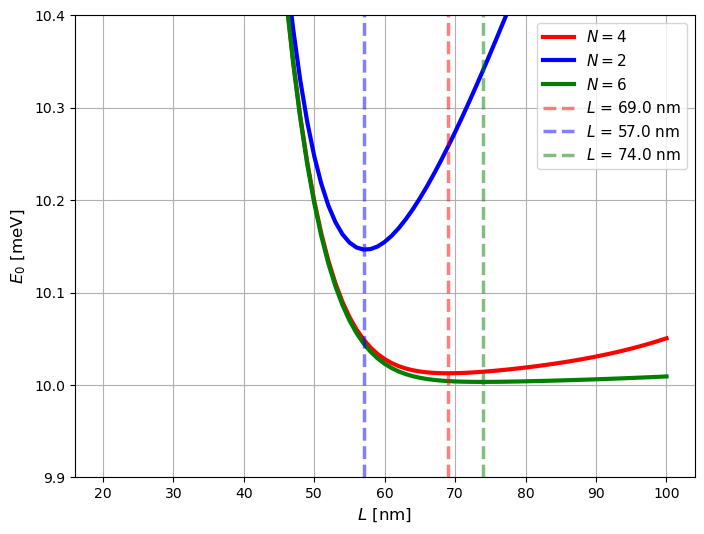

In [29]:
plt.figure(1, (8, 6))
plt.plot(LenghtsN4, np.array(E_optN4)*27211, color = "red", lw = 3, label = r"$N = 4$")
plt.plot(LenghtsN2, np.array(E_optN2)*27211, color = "blue", lw = 3, label = r"$N = 2$")
plt.plot(LenghtsN6, np.array(E_optN6)*27211, color = "green", lw = 3, label = r"$N = 6$")
plt.axvline(L_optN4, ymin = min(E_optN4), ymax = max(E_optN4)*1000, color = "red", alpha = 0.5, linewidth = 2.5, linestyle = "--", label = rf"$L$ = {L_optN4} nm")
plt.axvline(L_optN2, ymin = min(E_optN2), ymax = max(E_optN2)*1000, color = "BLUE", alpha = 0.5, linewidth = 2.5, linestyle = "--", label = rf"$L$ = {L_optN2} nm")
plt.axvline(L_optN6, ymin = min(E_optN6), ymax = max(E_optN6)*1000, color = "green", alpha = 0.5, linewidth = 2.5, linestyle = "--", label = rf"$L$ = {L_optN6} nm")
plt.xlabel(r"$L$ [nm]", fontsize = 12)
plt.ylabel(r"$E_{0}$ [meV]", fontsize = 12)
plt.grid()
plt.ylim(9.9, 10.4)
plt.legend(fontsize = 11)
plt.savefig("L_optymalne.pdf")

In [30]:
def element_size(mesh, nlg):
    x1 = x_of_xi(1, -1, -1, nlg, mesh)
    x2 = x_of_xi(1,  1, -1, nlg, mesh)
    return abs(x1 - x2)   

10.012602217042684


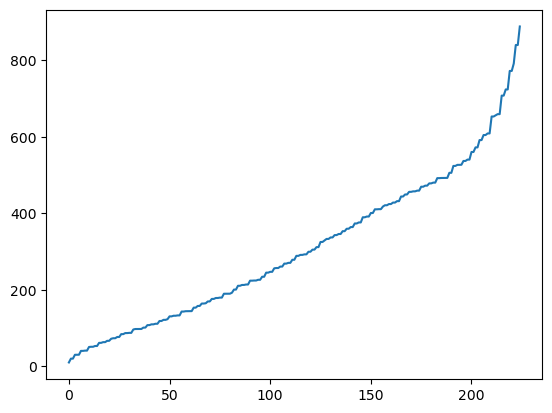

In [ ]:
Sg2, Hg2, Xg2 = SgHg(a=element_size(createMesh2(nodes_raw_N2_L100, L_optN2), nlgN2), kn=kn2, size=81, mesh=createMesh2(nodes_raw_N2_L100, L_optN2), nlg=nlgN2)
Sg4, Hg4, Xg4 = SgHg(a=element_size(createMesh2(nodes_raw_N4_L100, L_optN4), nlgN4), kn=kn4, size=289, mesh=createMesh2(nodes_raw_N4_L100, L_optN4), nlg=nlgN4)
Sg6, Hg6, Xg6 = SgHg(a=element_size(createMesh2(nodes_raw_N6_L100, L_optN6), nlgN6), kn=kn6, size=625, mesh=createMesh2(nodes_raw_N6_L100, L_optN6), nlg=nlgN6)

energies, _ = eigh(Hg4, Sg4)
energies = energies[energies > 0]
plt.plot(energies*27211)

In [32]:
def OptimalEnergy(H_global, S_global):
    energies, _ = eigh(H_global, S_global)
    mask = energies > 0
    energies_pos = energies[mask]

    return energies_pos

def LowestGroundEnergy(H_global, S_global):
    return OptimalEnergy(H_global=H_global, S_global=S_global)[0]

In [33]:
def FindGoodN():
    en2 = LowestGroundEnergy(Hg2, Sg2)
    en4 = LowestGroundEnergy(Hg4, Sg4)
    en6 = LowestGroundEnergy(Hg6, Sg6)

    N2vsN4 = np.abs(en4 - en2)/en2
    N2vsN6 = np.abs(en6 - en2)/en2
    N4vsN6 = np.abs(en6 - en4)/en4

    print(f"N2 vs N4: {N2vsN4*100}%")
    print(f"N2 vs N6: {N2vsN6*100}%")
    print(f"N4 vs N6: {N4vsN6*100}%")

In [34]:
FindGoodN()
local_T()

N2 vs N4: 1.3197905291467988%
N2 vs N6: 1.4117007532491666%
N4 vs N6: 0.0931394700064098%


array([[ 4.64344942e+00, -2.48756219e-01, -2.48756219e-01,
        -1.65837479e-01, -1.49253731e+00,  8.29187396e-01,
        -1.49253731e+00,  8.29187396e-01, -2.65339967e+00],
       [-2.48756219e-01,  4.64344942e+00, -1.65837479e-01,
        -2.48756219e-01, -1.49253731e+00, -1.49253731e+00,
         8.29187396e-01,  8.29187396e-01, -2.65339967e+00],
       [-2.48756219e-01, -1.65837479e-01,  4.64344942e+00,
        -2.48756219e-01,  8.29187396e-01,  8.29187396e-01,
        -1.49253731e+00, -1.49253731e+00, -2.65339967e+00],
       [-1.65837479e-01, -2.48756219e-01, -2.48756219e-01,
         4.64344942e+00,  8.29187396e-01, -1.49253731e+00,
         8.29187396e-01, -1.49253731e+00, -2.65339967e+00],
       [-1.49253731e+00, -1.49253731e+00,  8.29187396e-01,
         8.29187396e-01,  1.45936982e+01, -2.65339967e+00,
        -2.65339967e+00,  1.84073968e-10, -7.96019901e+00],
       [ 8.29187396e-01, -1.49253731e+00,  8.29187396e-01,
        -1.49253731e+00, -2.65339967e+00,  1.459369

In [35]:
import matplotlib.tri as mtri

En4, Cn4 = eigh(Hg4, Sg4)
mask = En4 > 0
En4_pos = En4[mask]
Cn4_pos = Cn4[:, mask]


idx_sort = np.argsort(En4_pos)
En4_sorted = En4_pos[idx_sort]
Cn4_sorted = Cn4_pos[:, idx_sort]

print("Pierwsze 10 energii [Ha]:")
print(En4_sorted[:10])

XY_opt = createMesh2(nodes_raw_N4_L100, L_optN4)
x_nodes = XY_opt[1:, 0]
y_nodes = XY_opt[1:, 1]

Pierwsze 10 energii [Ha]:
[0.00036796 0.0007372  0.0007372  0.00110644 0.00111274 0.00111274
 0.00148198 0.00148198 0.00150765 0.00150765]


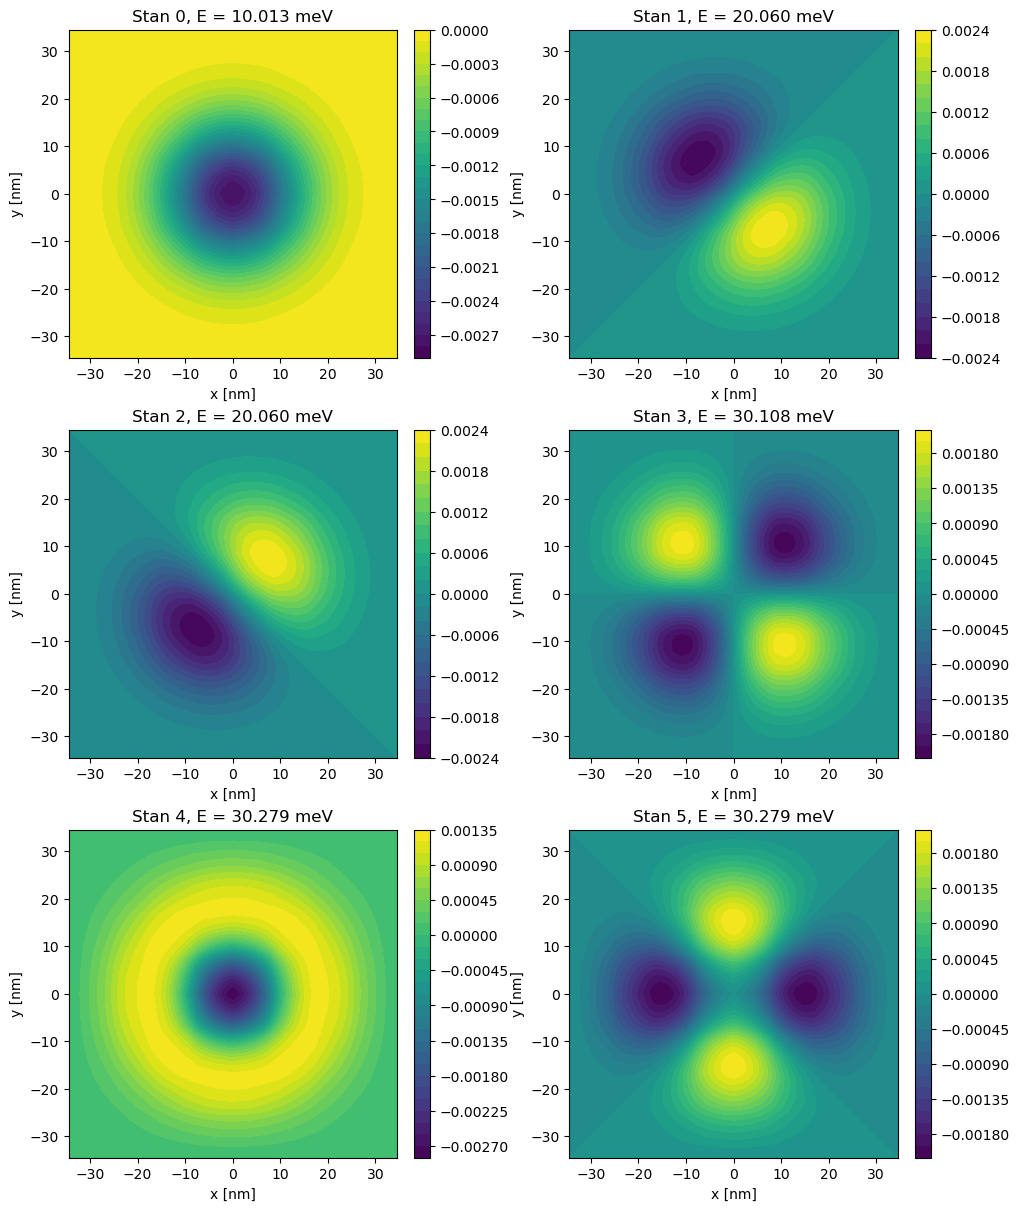

In [ ]:
def psi_on_element_k(n_state, k, xi1, xi2, C6, nlg, H):
    val = 0.0
    for i_loc in range(1, 10):          
        I = nlg[(k, i_loc)]        
        c_I = C6[I-1, n_state]
        val += c_I * H[i_loc-1](xi1, xi2)
    return val

import matplotlib.tri as mtri

xi = np.linspace(-1, 1, 21)
XI1, XI2 = np.meshgrid(xi, xi)

XY_opt = createMesh2(nodes_raw_N4_L100, L_optN4)

fig, axes = plt.subplots(3, 2, figsize=(10, 12), constrained_layout=True)  # 3 wiersze, 2 kolumny
axes = axes.ravel()

for n in range(6):
    ax = axes[n]

    X_all, Y_all, Z_all = [], [], []
    for k in range(1, kn4+1):
        for a in range(XI1.shape[0]):
            for b in range(XI1.shape[1]):
                xi1, xi2 = XI1[a, b], XI2[a, b]
                X_all.append(x_of_xi(k, xi1, xi2, nlgN4, XY_opt))
                Y_all.append(y_of_xi(k, xi1, xi2, nlgN4, XY_opt))
                Z_all.append(psi_on_element_k(n, k, xi1, xi2, Cn4_sorted, nlgN4, H))

    X_all = np.array(X_all)
    Y_all = np.array(Y_all)
    Z_all = np.array(Z_all)

    triang = mtri.Triangulation(X_all, Y_all)
    cf = ax.tricontourf(triang, Z_all, levels=30, cmap="viridis")
    fig.colorbar(cf, ax=ax)
    ax.set_xlabel("x [nm]")
    ax.set_ylabel("y [nm]")
    ax.set_title(f"Stan {n}, E = {En4_sorted[n]*27211.6:.3f} meV")
    ax.set_aspect("equal")

plt.savefig("6_stanow_najnizszych.pdf", bbox_inches="tight")
plt.show()

    



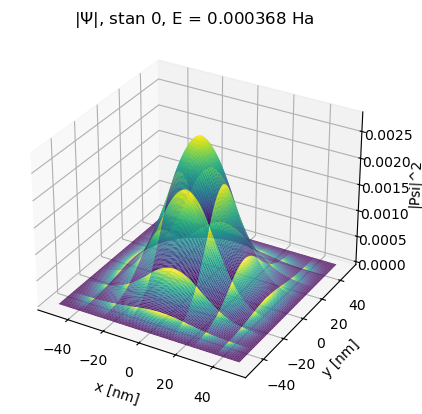

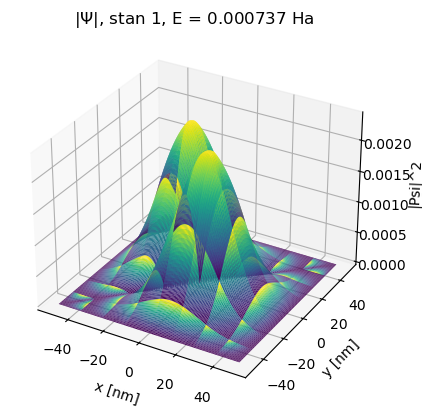

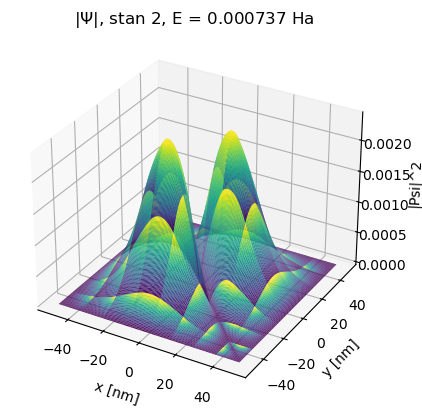

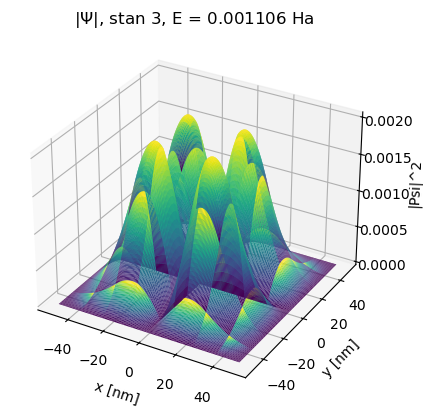

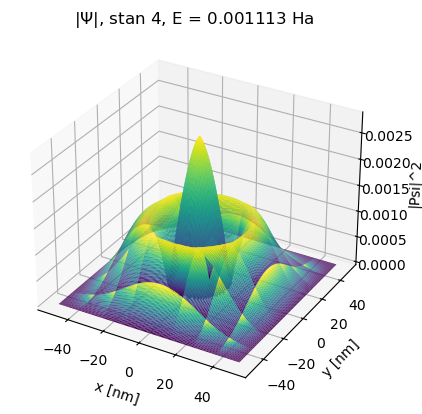

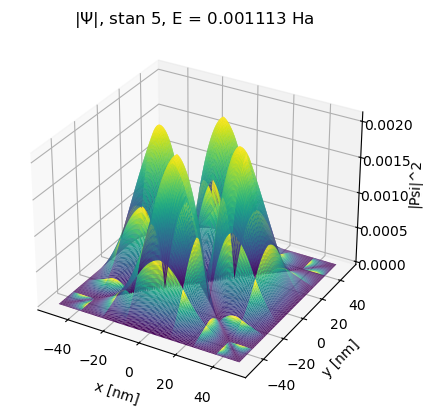

In [37]:
xi = np.linspace(-1, 1, 21)
XI1, XI2 = np.meshgrid(xi, xi)

for n in range(6):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    for k in range(1, kn4+1):
        Z = np.zeros_like(XI1)
        X = np.zeros_like(XI1)
        Y = np.zeros_like(XI1)
        for a in range(XI1.shape[0]):
            for b in range(XI1.shape[1]):
                xi1 = XI1[a, b]; xi2 = XI2[a, b]
                psi_val = psi_on_element_k(n, k, xi1, xi2, Cn4_sorted, nlgN4, H)
                Z[a, b] = np.abs(psi_val)
                X[a, b] = x_of_xi(k, xi1, xi2, nlgN4, XY_N4)
                Y[a, b] = y_of_xi(k, xi1, xi2, nlgN4, XY_N4)

        ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True)
    
    ax.set_title(Rf"$|\Psi|$, stan {n}, E = {En4_sorted[n]:.6f} Ha")
    ax.set_xlabel("x [nm]")
    ax.set_ylabel("y [nm]")
    ax.set_zlabel("|Psi|^2")
    plt.show()

In [38]:
E1, E2 = En4_sorted[0], En4_sorted[1]  
C1, C2 = Cn4_sorted[:, 0], Cn4_sorted[:, 1]
d0 = C1 + C2


In [39]:
dt = 100
T = 2*np.pi/np.abs(E2 - E1)
print(f"T_theory = {T}")
alpha = 0.5*dt/1j

from scipy.linalg import lu_factor, lu_solve

S_sub_H = Sg4 - alpha * Hg4
S_add_H = Sg4 + alpha * Hg4
times_to_save = [0.0, T/4, T/2, 3*T/4]
snapshots = {}

T_theory = 17016.550868131948


In [40]:
lu, piv = lu_factor(S_sub_H)
d = d0.astype(complex)
steps = 1000

xs = []
ts = []

for n in range(steps):
    t = n*dt
    x_t = np.vdot(d, Xg4 @ d).real
    xs.append(x_t)
    ts.append(t)

    for tt in times_to_save:
        if np.isclose(t, tt, atol=dt/2):
            snapshots[tt] = d.copy()

    rhs = S_add_H @ d
    d = lu_solve((lu, piv), rhs)

xs_np = np.array(xs)
ts_np = np.array(ts)

In [41]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(xs_np)
t_peaks = ts_np[peaks]
T_num = np.mean(np.diff(t_peaks))
print(T_num, T_num * 2.418884e-5, "ps")
print(f"Błąd względem kroku teoretycznego: {(np.abs(T_num - T)/T)*100:.2f}%")

17040.0 0.4121778336 ps
Błąd względem kroku teoretycznego: 0.14%


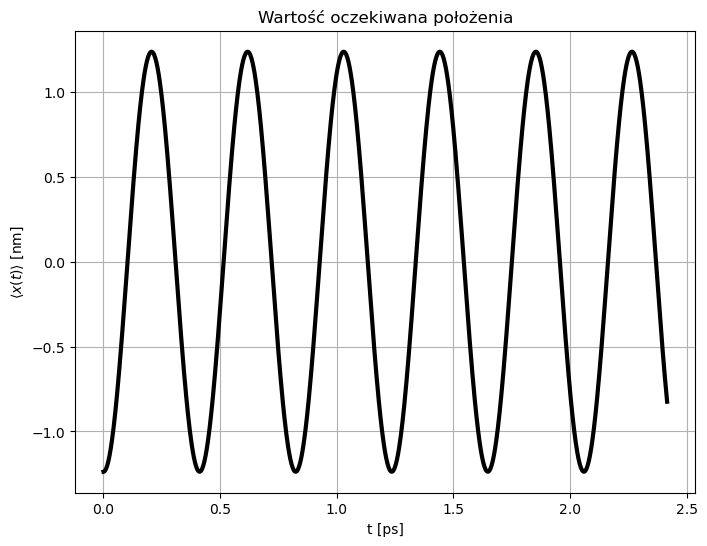

In [42]:
plt.figure(1, (8, 6))
plt.plot(ts_np*2.418884e-5, xs_np*0.05292, color="black", lw=3)
plt.xlabel("t [ps]")
plt.ylabel(r"$\langle x(t) \rangle$ [nm]")
plt.title("Wartość oczekiwana położenia")
plt.grid()
plt.savefig("Wartosc_oczekiwana_polozenia.pdf")


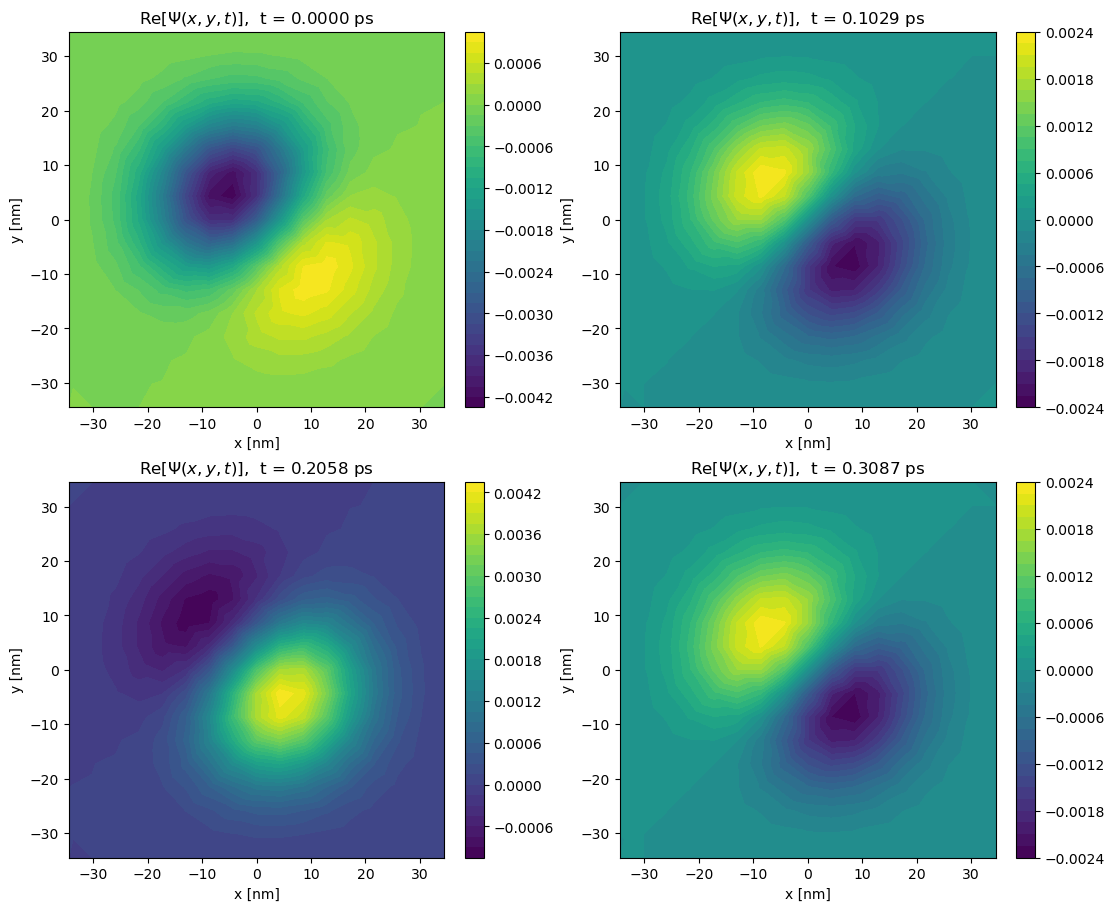

In [43]:
XY_opt = createMesh2(nodes_raw_N4_L100, L_optN4)
x_nodes = XY_opt[1:, 0]
y_nodes = XY_opt[1:, 1]

import matplotlib.tri as mtri
triang_nodes = mtri.Triangulation(x_nodes, y_nodes)   

times = sorted(snapshots.keys())[:4]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
axes = axes.ravel()

for ax, t in zip(axes, times):
    d_t = snapshots[t]
    amp = d_t.real

    cf = ax.tricontourf(triang_nodes, amp, levels=40, cmap="viridis")
    
    fig.colorbar(cf, ax=ax)
    ax.set_title(rf"Re[$\Psi(x,y,t)$],  t = {t*2.418884e-5:.4f} ps")
    ax.set_xlabel("x [nm]")
    ax.set_ylabel("y [nm]")
    ax.set_aspect("equal")

plt.savefig("Ewolucja_czasowa.pdf", dpi =300)
plt.show()
